This notebook trains a L2R, R2L, and alternating MAE model on epoch: 1702827001820 (two minutes of data in Dec '23 Nor'easter on Dec 17 at 10:30 am) and applies the trained model onto two minutes of synthetic data modeled after the same storm and time period.

Goal: Look at model predictions incrementally. 

Key differences from testingtime1:
- data is detrened using lowpass filter rather than normalized

In [46]:
import matplotlib.pyplot as plt
import numpy as np
#np.long = int 
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73
import gc
from scipy.io import loadmat

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image


import keras
from matplotlib.animation import FuncAnimation
import seaborn as sns
from scipy import signal
import re

**PATHS**

In [47]:
modelsavepath=r'/Volumes/kanarde/MasonBEAST/data/trained_models/demeaned_trainingdata/'
#'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/trained_models/'
savepath=r'/Volumes/kanarde/MasonBEAST/data/testingtime1'
#'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/testingtime1/'
transect_1702827001820_path=r'/Volumes/kanarde/MasonBEAST/data/DEMs/1702827001820/Transects/alongshore_transects.mat'

figpath1820=os.path.join(savepath,'1702827001820/Figures/')
savepath1820=os.path.join(savepath,'1702827001820/')

figpathSYN=os.path.join(savepath,'1702827001820/Figures/Synthetic/') # synthetic data
savepathSYN=os.path.join(savepath,'1702827001820/Synthetic/') # synthetic data


**FUNCTIONS FOR PREPPING DATA**
- load data from .mat file
- reorder
- detrend using lowpass filter
- assessing point density

In [48]:
def loadNprep(training_datapath):
    # This function takes a path to a .mat file of transects in the form of a matrices (cross-shore pts x timesteps) 
    # imbedded in a larger structure (generated from ptcld2DEM2transects_process.m) and outputs dataframes of 
    # the transects
    raw_mat=loadmat(training_datapath)
    train_struct=raw_mat['tran_struct']

    all_trans=[]
    names=[]

    for elem in train_struct.ravel():
        name=elem['name'].item()
        data_matrix=elem['data']

        temp_df=pd.DataFrame(data_matrix)
        temp_df['name']=name

        all_trans.append(temp_df)
        names.append(name)

    train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
    train_ds1=train_trans_df.drop(columns=['name'])
    print("Dataset 1 Shape:", train_ds1.shape)

    return train_ds1

In [49]:
def detrend_ds(ds,filter_wn=0.05,filter_order=2):
    # This function lowpass filters a dataset along time, computes a mean for each point in the dataset, and subtracts it from the original dataset. 

    # Inputs:
    # ds = pd.Dataframe with muliIndex rows (transect) and timesteps as columns
    # filter_wn = low pass filter normailex cutoff frequency (0<wn<1)
    # filter_order = butterworth filter order (steepness of frequency rolloff)

    # Outputs: 
    # ds_demeaned = pd.Dataframe with original water elevations with low-pass mean removed
    # avg_mwl = pd.Series of mean water level (index by MultiIndex)
    # ds_lp = pd.Dataframe of the full low pass filtered time series


    # interpolate NaNs for filtering (will remove later)
    ds_filled=ds.interpolate(method='linear', axis=1, limit_direction='both')
    ds_filled=ds_filled.fillna(0) # for if it is all NaNs

    # low pass filter each point across all timesteps
    b,a=signal.butter(N=filter_order,Wn=filter_wn,btype='low')
    lp_matrix=signal.filtfilt(b,a,ds_filled.values,axis=1)

    ds_lp=pd.DataFrame(lp_matrix,index=ds.index,columns=ds.columns)
    ds_lp[ds.isna()]=np.nan # put nans back into transects

    avg_mwl=ds_lp.mean(axis=1,skipna=True) # mean per point (over time) in DEM

    ds_demeaned=ds.sub(avg_mwl,axis=0) # subtract mean out of og water level

    return ds_demeaned, avg_mwl, ds_lp


In [50]:
def add_mean(ds_demeaned, avg_mwl):
    # restore original water level by adding back mean
    # This worked with predicted values over previous Nans

    return ds_demeaned.add(avg_mwl,axis=0)

In [51]:
def sort_transects(ds,descending=True):
    transects={transect_name:group.droplevel('transect_name') for transect_name,group in ds.groupby(level='transect_name')}
    print(f"{len(transects)} transects in given ds")
    import re
    # sort chronologicallly
    def extract_y_loc(name):
        match=re.search(r'y([-+]?\d+\.?\d*)',name)
        if match:
            return float(match.group(1))
        return 0
    sorted_transect_keys=sorted(transects.keys(),key=extract_y_loc,reverse=descending)
    sorted_transects={k:transects[k] for k in sorted_transect_keys}
    return sorted_transects

In [52]:
def plot_density(pt_density,savepath,epochnum):
    os.makedirs(savepath,exist_ok=True)
    savepath=os.path.join(savepath,"point_density.png")
    # plot density of transects (amount of original data present) 
    import seaborn as sns
    import pandas as pd
    df=pd.DataFrame(pt_density)

    plt.figure(figsize=(16,12))
    sns.heatmap(df.T.iloc[::-1],cmap='seismic',annot=False,xticklabels=15,yticklabels=True,cbar_kws={'label':'density'})
    plt.title(f'# of Points in Transects over time at Epoch {epochnum}',fontsize=14)
    plt.xlabel('timestep',fontsize=12)
    plt.ylabel('transect',fontsize=12)

    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8,rotation=0)

    plt.tight_layout()
    plt.savefig(savepath,dpi=300,bbox_inches='tight')
    plt.show()
    

**PREP DATA**

Load in data and access point density

Dataset 1 Shape: (23693, 239)
43 transects in given ds


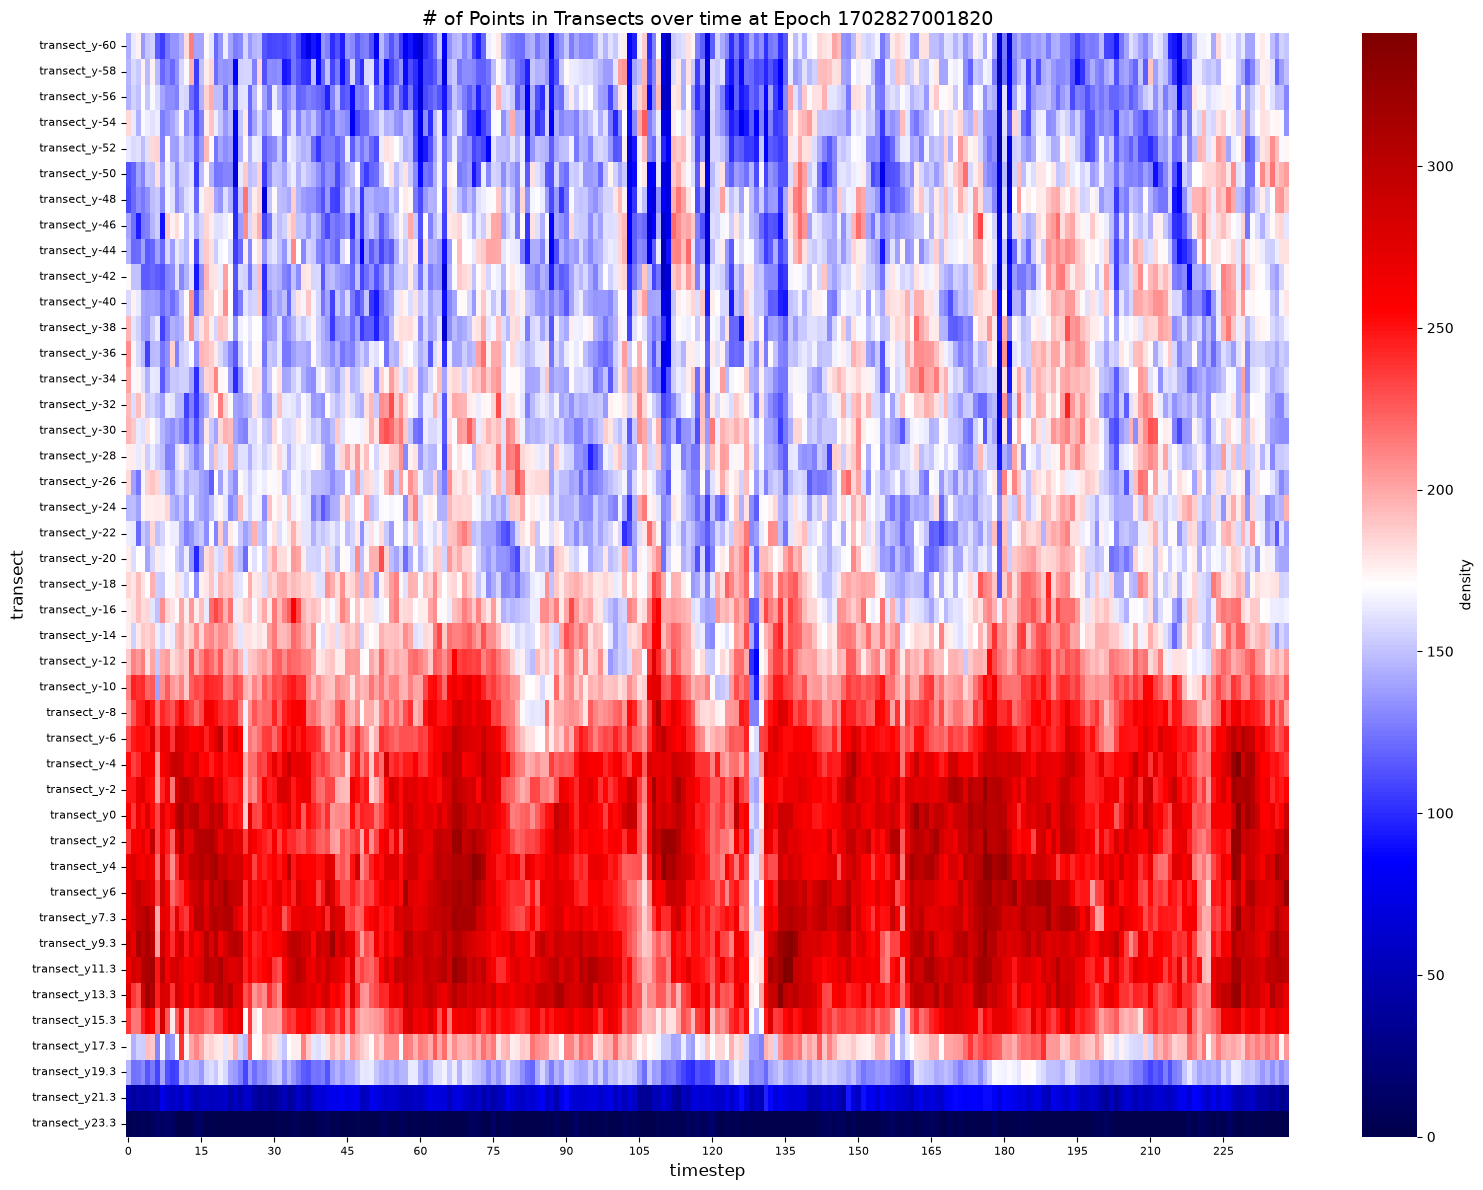

In [32]:
tran1702827001820=loadNprep(transect_1702827001820_path) # load
sorted_1820_dict=sort_transects(tran1702827001820,descending=True) #sort
sorted_1820=pd.concat(sorted_1820_dict.values(), keys=sorted_1820_dict.keys()) # dataframe

# point density 
pt_density_1820 = pd.DataFrame( {t_name: sorted_1820_dict[t_name].iloc[200:].count() for t_name in sorted_1820_dict.keys()} ) 
plot_density(pt_density_1820,figpath1820,'1702827001820')

plt.close('all')

Detrend data (aka normalize by low pass filtering)

In [53]:
ds1820_demeaned,avg_mwl1820,ds1820_lp=detrend_ds(sorted_1820.iloc[200:,:],filter_wn=0.05,filter_order=2) 

In [66]:
print(type(sorted_1820))
print(sorted_1820.shape) # sorted is all the points and timesteps w/ labels
print(sorted_1820)

<class 'pandas.DataFrame'>
(23693, 239)
                                0   1   2   3   4   5   6   7   8   9  ...  \
               original_index                                          ...   
transect_y23.3 0              NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               1              NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               2              NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               3              NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               4              NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
transect_y-60  546            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               547            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               548            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               549            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
               550      

In [ ]:
print(type(ds1820_demeaned))
print(ds1820_demeaned.shape) # demeaned is output at all the points and timesteps w/ labels (does not include dune points... will need to add back in)
print(ds1820_demeaned)

<class 'pandas.DataFrame'>
(23493, 239)
                                      0         1         2         3  \
               original_index                                           
transect_y23.3 200                  NaN -0.094909       NaN -0.129449   
               201            -0.061901 -0.069154       NaN       NaN   
               202            -0.062647 -0.061753 -0.131859       NaN   
               203            -0.055487 -0.068476 -0.124293 -0.156087   
               204                  NaN -0.033386 -0.075610 -0.107571   
...                                 ...       ...       ...       ...   
transect_y-60  546                  NaN       NaN       NaN       NaN   
               547                  NaN       NaN       NaN       NaN   
               548                  NaN       NaN       NaN       NaN   
               549                  NaN       NaN       NaN       NaN   
               550                  NaN       NaN       NaN       NaN   

          

In [54]:
# add functions for plotting the residuals and demeaning
def plot_detrending(
    ds_obs,
    ds_lowpass,
    ds_detrended,
    target_transect,
    target_pt,
    savepath=None,
):
    """Plots original water level, low-pass mean filter, and demeaned residuals

    for a specific transect and spatial point across all timesteps.
    """
    # Extract time series for the target transect and point index
    obs = ds_obs.loc[(target_transect, target_pt)]
    lp_mean = ds_lowpass.loc[(target_transect, target_pt)]
    demeaned = ds_detrended.loc[(target_transect, target_pt)]
    tsteps = ds_obs.columns

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    # Top Plot: Observed Water Level vs Low-Pass Filter
    axes[0].plot(
        tsteps,
        obs.values,
        color="navy",
        label="Observed Water Level",
        alpha=0.7,
    )
    axes[0].plot(
        tsteps,
        lp_mean.values,
        color="deeppink",
        linewidth=2,
        label="Low-pass Mean Filter",
    )
    axes[0].set_title(
        f"Observed WL and Low-pass Mean ({target_transect}, Point"
        f" {target_pt})",
        fontsize=12,
    )
    axes[0].set_ylabel("Water Level (m)", fontsize=10)
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend(loc="upper right")

    # Bottom Plot: Demeaned Residuals
    axes[1].plot(
        tsteps,
        demeaned.values,
        color="teal",
        linewidth=1.5,
        label="Demeaned Residuals",
    )
    axes[1].axhline(0, color="black", linestyle=":", alpha=0.7)
    axes[1].set_title(
        "Demeaned Water Level (Obs - Lowpass Mean)", fontsize=12
    )
    axes[1].set_xlabel("Timestep", fontsize=10)
    axes[1].set_ylabel("Water Level (m)", fontsize=10)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend(loc="upper right")

    plt.tight_layout()

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, axes

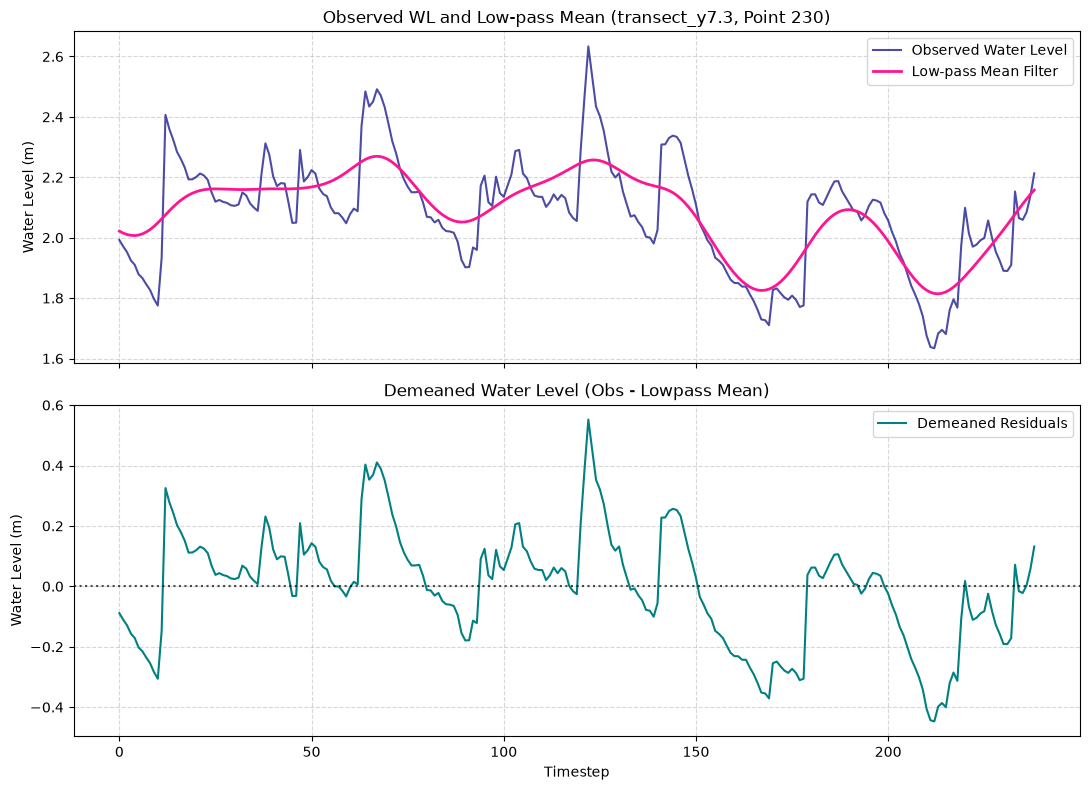

In [56]:
fig, axes = plot_detrending(
    ds_obs=tran1702827001820,
    ds_lowpass=ds1820_lp,
    ds_detrended=ds1820_demeaned,
    target_transect="transect_y7.3",
    target_pt=230,
    savepath="plots/detrending_y7.3_pt230.png",  # Optional
)

**FUNCTIONS TO TRAIN L2R MODEL**

In [57]:
def define_L2R_functions():
    # this function trains defines the L2R model and the functions needed to train the model

    # define model
    class Denoise(Model):
        def __init__(self,window_size,**kwargs):
            super(Denoise,self).__init__(**kwargs)
            self.window_size=window_size

            self.enc_input = layers.InputLayer(shape=(window_size, 2)) 
            self.enc_conv1 = layers.Conv1D(32, 3, activation='relu', padding='same', strides=2) 
            self.enc_conv2 = layers.Conv1D(16, 3, activation='relu', padding='same', strides=2) 
            self.enc_conv3 = layers.Conv1D(8, 3, activation='relu', padding='same', strides=2)
            #self.encoder=tf.keras.Sequential([
                #layers.Input(shape=(window_size,2)), # changed from none
                #layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
                #layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
                #layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
            #])
            self.dec_tr1 = layers.Conv1DTranspose(8, 3, strides=2, activation='relu', padding='same') 
            self.dec_tr2 = layers.Conv1DTranspose(16, 3, strides=2, activation='relu', padding='same') 
            self.dec_tr3 = layers.Conv1DTranspose(32, 3, strides=2, activation='relu', padding='same') 
            self.dec_flat = layers.Flatten() 
            self.dec_dense = layers.Dense(window_size, activation='sigmoid') 
            self.dec_reshape = layers.Reshape((window_size, 1))

            #self.decoder=tf.keras.Sequential([
                #layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
                #layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
                #layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
                #layers.Flatten(),
                #layers.Dense(window_size,activation='sigmoid'),
                #layers.Reshape((window_size,1))
            #])

        def call(self,x):
            #encoded=self.encoder(x)
            #decoded=self.decoder(encoded)
            #x = self.enc_input(x) 
            x = self.enc_conv1(x) 
            x = self.enc_conv2(x) 
            encoded = self.enc_conv3(x) # Pass through individual Decoder layers 
            x = self.dec_tr1(encoded) 
            x = self.dec_tr2(x) 
            x = self.dec_tr3(x) 
            x = self.dec_flat(x) 
            x = self.dec_dense(x) 
            decoded = self.dec_reshape(x)
            return decoded
        
        def get_config(self): 
            config = super(Denoise, self).get_config() 
            config.update({ "window_size": self.window_size, }) 
            return config
        @classmethod 
        def from_config(cls, config): 
            return cls(**config)
    
        def train_step(self,data):
            # to get input tensor (x_input,y) from .map() in mask
            x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

            with tf.GradientTape() as tape: 
                # forward pass using x_masked
                y_pred=self(x_input,training=True)
                mse=tf.square(y_pred-y) #calc loss
                masked_mse=mse*(1.0 - mask) # masked loss
                loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
           
            trainable_vars=self.trainable_variables
            gradients=tape.gradient(loss,trainable_vars)
            self.optimizer.apply_gradients(zip(gradients,trainable_vars))

            return{"loss":loss}
    
        def test_step(self,data):
            # to get input tensor
            x,y,mask,start_idx,t_step=data
 
            y_pred=self(x,training=False)
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

            return {"loss":loss}

    def gap_mask(x,mask_ratio):
        #batch_size=tf.shape(x)[0]
        length=tf.shape(x)[0]# number of things in x, x is (10,1)

        gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
        gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
        max_start=tf.maximum(length-gap_size,0) #mask starts inside window

        start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

        range_idx=tf.range(length) # (length,) 
        #boolean mask
        if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

        gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
        gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
        mask=1-gap_mask_tensor
        x_masked=x*mask
        return x_masked,mask

    def random_mask(x,mask_ratio):
        mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
        x_masked=x*mask
        return x_masked, mask


    def masking_layer(x,start,t_step):
        window_size=tf.shape(x)[0]
        x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
        mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

        use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
        #mask via gap and random method
        x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))
        x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)
        return x_input,x, mask, start, t_step# (given data and target/real og data)

    def prep_training(train_source_df,split_windows_idx,batch_size=16):
        # windows of training/testing/vaidation data
        # run MAE training cycle per targeted window size
        timesteps=sorted(split_windows_idx.keys()) #chronological order
        n=len(timesteps)

        # train/val/test bounds
        train_end=int(n*0.7)
        val_end=int(n*0.85)

        train_time=timesteps[:train_end] #slice to grab train/test/val
        val_time=timesteps[train_end:val_end]
        test_time=timesteps[val_end:]

        def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
            X, info = [],[]
            for t in time_list:
                transect=train_source_df[t].values #grab from static training source
            
                for (start,stop) in split_windows_idx[t]: # windows of chosen size
                    X.append(transect[start:stop])
                    info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
                
            return np.array(X, dtype="float32"), info
    
        X_train, info_train=grab_windows(train_time)
        X_val, info_val=grab_windows(val_time)
        X_test, info_test=grab_windows(test_time)

        print(f"Window count --- Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

        # create ds function (mem efficient)
        def build_ds(X,info):
            if len(X) ==0:
                print("0 windows found, non-nan segments are shorter than window size")

            starts=np.array([i['start'] for i in info]) # start points spatial
            tsteps=np.array([i['timestep'] for i in info]) # end points spatial
            ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
            # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
            return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=False).prefetch(tf.data.AUTOTUNE))
    
        train_ds=build_ds(X_train,info_train)
        test_ds=build_ds(X_test,info_test)
        val_ds=build_ds(X_val,info_val)

        return train_ds, val_ds, test_ds
    def window_split(start,stop,size,overlap):
        return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]
    # define functions for training
    def is_gap_too_big(mask,window_size):
        mask_str="".join(mask.astype(int).astype(str))
        return "0"*window_size in mask_str
    def run_MAE(window_size,train_ds,val_ds, epochs=20,model=None):
        # inirialize model
        if model is None:
            model=Denoise(window_size=window_size)
            model.compile(optimizer='adam')
        else: 
            print("training on pre-existing model")
            model.compile(optimizer='adam')

        history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
        return model, history
    
    def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
        # slides MAE over the transects from left to right to impute where gaps exist
        # returns newly filled dataset
        x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
        transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps
        mask_matrix=active_mask_df.values.astype(np.float32)

        reconstructed_all=[]

        for i in range(tsteps): # loop through every time step
            x_1dim=x_matrix[:,i].numpy() #current transect
            mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
            valid_indices=np.where(mask_1dim==1.0)[0]
            if len(valid_indices)>0:
                last_valid_index=valid_indices[-1]
            else:
                last_valid_index=-1

            full_recon=np.zeros_like(x_1dim) 
            counts=np.zeros_like(x_1dim)

            # slide window over full transect profile
            for start in range(0,transect_pts-window_size+1,stride):
                end=start+window_size
                #window_raw=raw_1dim[start:end] # window of raw data
                window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
                window_mask=mask_1dim[start:end] #
                #model input shape
                combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim
                # CHECKS
                is_already_full = np.all(window_mask == 1.0) # check if window is full
                has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

                if is_already_full:# PATH1: do not predict if full of data
                    #keep full window
                    full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                    counts[start:end] += 1
                    continue

                if has_gap_inside: # PATH2: predict in window
                    gap_indices=np.where(window_mask==0.0)[0]
                    total_real_data_pts=np.sum(window_mask==1.0)
                    min_context_pts=1 #threshold of at least one point
                    has_any_local_context=total_real_data_pts>=min_context_pts

                    full_gap_idx=start+gap_indices[0]
                    g_start=full_gap_idx
                    if is_gap_too_big(window_mask,window_size=window_size):
                        #g_start=full_gap_idx
                        while g_start>0 and mask_1dim[g_start-1]==0.0:
                            g_start-=1
                        g_end=start+gap_indices[-1]
                        while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                            g_end+=1
                        gap_size=g_end - g_start +1
                        #print(f"gap size is {gap_size}")
                        if gap_size > window_size: # gap too big (outside of window)
                            #print(f"t index {i} skipped gap ({start}:{end}) too large")
                            continue
                    # Check1: Is it bounded by real data on window edge?
                    has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
                    # Check2: if on window edge, is there data outside of window edge
                    left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
                    right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
                    both_sides_bounded=left_bound or right_bound
                    is_bounded=both_sides_bounded or has_bounds
                    if has_any_local_context and is_bounded:
                        model_recon = model.predict(combined_input, verbose=0).flatten()
                        # keep original data
                        recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                        #preds for avg
                        #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                        full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                        counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gaps

            raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
            nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window
            # get rid of prediction into the abysss
            if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
                raw_prediction[last_valid_index+1:]=np.nan
            final_transect=raw_prediction.copy()
            is_gap=(mask_1dim==0) # find gap
            gap_changes=np.diff(is_gap.astype(int))

            gap_starts=np.where(gap_changes==1)[0]+1
            gap_ends=np.where(gap_changes==-1)[0]

            # at the edge
            if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
            if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
            # smooth over transistion (2-4 data points of smoothing with favor to the real data)
            blend_zone=min(4,int(window_size/4)) # transistion blending margin
            for g_start,g_end in zip(gap_starts,gap_ends):
                current_gap_size=g_end-g_start+1
                if current_gap_size<=6: # don't blend over the small gaps
                    continue
                #left side blend
                if g_start>blend_zone:
                    anchor_val=x_1dim[g_start -1] #known real value
                    for b in range(blend_zone):
                        idx=g_start+b
                        if idx<= g_end and not np.isnan(raw_prediction[idx]):
                            # linear transition (Could do something better) from anchor to pred
                            alpha=(b+1)/(blend_zone +1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
                #right side
                if g_end< len(x_1dim)-1:
                    right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                    if mask_1dim[right_anchor_idx]==1.0: 
                        anchor_val=x_1dim[g_end+1]
                        for b in range(blend_zone):
                            idx=g_end-b
                            if idx>=g_start and not np.isnan(raw_prediction[idx]):
                                alpha=(b+1)/(blend_zone+1)
                                final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]

            # overide to keep og data (kind of like a fail safe if the rest didn't work)
            final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
            #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
            reconstructed_all.append(final_transect)
        # return dataframe (points, timesteps)
        return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns,index=current_df.index)

    def find_windows_of_data(df,window_size,overlap_stride):
        # find the continous sections of data and extract window indices
        window_idx={}
        for timestep,transect in df.items():
            arg=transect.values
            masked=np.ma.masked_invalid(arg)
            clumps=np.ma.clump_unmasked(masked)
            window_idx[timestep]=[(s.start,s.stop)for s in clumps]

        split_windows_idx={}
        for timestep in window_idx:
            new_windows=[]
            for (start,stop) in window_idx[timestep]:
                length=stop-start
                if length>= window_size:
                    new_windows.extend(window_split(start,stop,window_size,overlap_stride))
            split_windows_idx[timestep]=new_windows
        return split_windows_idx

    return {
        "Denoise": Denoise,
        "prep_training":prep_training,
        "run_MAE": run_MAE,
        "reconstruct_ds_with_MAE": reconstruct_ds_with_MAE,
        "find_windows_of_data": find_windows_of_data,
        "window_split":window_split
    }

In [99]:
def define_plotting_functions():
    from collections import Counter
    def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label="",savepath=""):
        # functiin to histogram after reconstruction
        mask_matrix=active_mask_df.values
        spatial_pts,tsteps=mask_matrix.shape
        all_window_lengths=[]
        for col in range(tsteps):
            column=mask_matrix[:,col]
            is_target=(column==target_val) # find zeros
            # pad edges to get everything
            bound=np.hstack(([False],is_target,[False]))
            diffs=np.diff(bound.astype(int))

            starts=np.where(diffs==1)[0]
            ends=np.where(diffs==-1)[0]
            lengths=ends-starts

            all_window_lengths.extend(lengths)

        filtered_lengths=[l for l in all_window_lengths if l>=min_length]

        freq_map=Counter(filtered_lengths)
        mode_size=freq_map.most_common(1)[0][0]

        print(f"mode: {mode_size}")
        print(f"max length: {max(filtered_lengths)}")
        print(f"min length: {min(filtered_lengths)}")

        if plot_histogram:
            plt.figure(figsize=(9,4))
            plt.hist(filtered_lengths,bins=np.arange(min(filtered_lengths)-0.5, max(filtered_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
            plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
            plt.title(f'distribution of continous data segments')
            plt.xlabel('segment length')
            plt.ylabel('freq')
            plt.legend()
            plt.grid(axis='y',linestyle=':',alpha=0.6)
            filename=f"histogram_{stage_label}.png"
            filepath=os.path.join(savepath,filename)
            plt.savefig(filepath,bbox_inches='tight')
            plt.close()
            return mode_size
    def save_stage_video_animation(
        orig_df,
        recon_df,
        window_size,
        stage_dir="stage_outputs",
        interval=500,
        include_dune=True,
        filename_prefix="profile_animation"
    ):
        """
        Creates dynamic reconstruction video animations.
   
        - include_dune=True: Stitches original dune (0..199) to lower beach recon (200..550) + mean added.
        - include_dune=False: Takes demeaned lower beach orig_df (ds) and recon_df (351 points each)
        and positions them across indices 200..550 with NaN placeholder for 0..199.
        """
        os.makedirs(stage_dir, exist_ok=True)
   
        DUNE_OFFSET = 200
        TOTAL_POINTS = 551
   
        orig_data = orig_df.values     # Shape: (551, t) or (351, t)
        recon_data = recon_df.values   # Shape: (351, t) or (551, t)
   
        n_timesteps = orig_data.shape[1]
        x_coords = np.arange(TOTAL_POINTS)

        fig, ax = plt.subplots(figsize=(12, 5))
   
        # Calculate Y-limits dynamically ignoring NaNs
        all_valid = np.concatenate([
            orig_data[~np.isnan(orig_data)],
            recon_data[~np.isnan(recon_data)]
        ])
        y_min, y_max = (np.min(all_valid), np.max(all_valid)) if len(all_valid) > 0 else (-1.0, 1.0)
   
        ax.set_xlim(0, TOTAL_POINTS)
        ax.set_ylim(y_min - 0.1, y_max + 0.1)
        ax.set_xlabel("Full Cross-shore Index")
        ax.set_ylabel("Elevation (m)" if include_dune else "Demeaned Elevation (m)")
   
        label_recon = f'MAE-{window_size} Recon'
        label_orig = 'Original Survey' + (' (with Dune)' if include_dune else ' (Demeaned Lower Beach)')
   
        line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=label_recon)
        line_orig, = ax.plot([], [], color='blue', alpha=0.6, label=label_orig)
   
        # Vertical line indicating dune boundary
        ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff (index 200)')

        gap_spans = []
        gap_patch = plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
        ax.legend(handles=[line_orig, line_recon, gap_patch], loc='lower left')

        def update(frame):
            nonlocal gap_spans
            for span in gap_spans:
                span.remove()
            gap_spans.clear()

            y_orig_full = np.full(TOTAL_POINTS, np.nan)
            y_recon_full = np.full(TOTAL_POINTS, np.nan)

            # -------------------------------------------------------------------
            # Map Original Data onto 551-point Canvas
            # -------------------------------------------------------------------
            if orig_data.shape[0] == 351:
                # Place lower-beach ds at 200..550 (0..199 remains NaN)
                y_orig_full[DUNE_OFFSET:] = orig_data[:, frame]
            else:
                # Full profile
                y_orig_full[:] = orig_data[:, frame]
                if not include_dune:
                    y_orig_full[:DUNE_OFFSET] = np.nan

            # -------------------------------------------------------------------
            # Map Reconstruction Data onto 551-point Canvas
            # -------------------------------------------------------------------
            recon_lower = recon_data[:, frame] if recon_data.shape[0] == 351 else recon_data[DUNE_OFFSET:, frame]

            if include_dune:
                # Stitch original dune (0..199) + recon lower beach (200..550)
                y_recon_full[:DUNE_OFFSET] = y_orig_full[:DUNE_OFFSET]
                y_recon_full[DUNE_OFFSET:] = recon_lower
            else:
                # NaN placeholder for dune (0..199) + demeaned recon (200..550)
                y_recon_full[DUNE_OFFSET:] = recon_lower

            # Highlight data gaps on lower beach (indices 200..550)
            is_gap = np.isnan(y_orig_full)
            is_gap[:DUNE_OFFSET] = False  # Ignore dune region

            if np.any(is_gap):
                diff = np.diff(is_gap.astype(int))
                gap_starts = np.where(diff == 1)[0] + 1
                gap_ends = np.where(diff == -1)[0] + 1

                if is_gap[0]:
                    gap_starts = np.insert(gap_starts, 0, 0)
                if is_gap[-1]:
                    gap_ends = np.append(gap_ends, TOTAL_POINTS - 1)

                for start, end in zip(gap_starts, gap_ends):
                    span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                    gap_spans.append(span)

            line_recon.set_data(x_coords, y_recon_full)
            line_orig.set_data(x_coords, y_orig_full)
       
            mode_title = "With Dune (Mean Added)" if include_dune else "Demeaned (Dune Placeholder)"
            ax.set_title(f"Reconstruction [{mode_title}] | Stage: MAE-{window_size} | Timestep: {frame}")
            return [line_orig, line_recon] + gap_spans

        anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
        video_path = os.path.join(stage_dir, f"{filename_prefix}_MAE{window_size}.gif")
        anim.save(video_path, writer="pillow")
        plt.close()  
    
    def save_stage_loss_plot(history, window_size, stage_dir='stage_results'):
        """
        Plots and saves the training (and validation) loss over epochs for a given training iteration.
    
        Parameters:
        -----------
        history : keras.callbacks.History or dict
            The training history object or dictionary returned by run_MAE.
        window_size : int
            The current window size used in this training iteration (used for the filename/title).
        stage_dir : str
            The directory path where the plot image will be saved.
        """
        # 1. Ensure the output directory exists
        os.makedirs(stage_dir, exist_ok=True)
    
        # 2. Extract the history dictionary if a Keras History object is passed
        if hasattr(history, 'history'):
            history_dict = history.history
        else:
            history_dict = history

        # 3. Retrieve loss arrays
        loss = history_dict.get('loss', [])
        val_loss = history_dict.get('val_loss', [])
        epochs = range(1, len(loss) + 1)

        if len(loss) == 0:
            print(f"Warning: No 'loss' data found in history for window size {window_size}.")
            return

        # 4. Generate the plot
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, loss, color='#1f77b4', linestyle='-', linewidth=2, label='Training Loss')
    
        if val_loss:
            plt.plot(epochs, val_loss, color='#d62728', linestyle='--', linewidth=2, label='Validation Loss')
        
        plt.title(f'Training Loss (Window Size: {window_size})', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=11, loc='upper right')
    
        # 5. Save the figure with high resolution
        filename = f"loss_window_{window_size}.png"
        filepath = os.path.join(stage_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
    
        # 6. Close the plot to free memory (crucial inside a loop)
        plt.close()
        print(f"-> Successfully saved loss plot to: {filepath}")

    return {
        "reeval_and_hist": reeval_and_hist,
        "save_stage_video_animation": save_stage_video_animation,
        "save_stage_loss_plot": save_stage_loss_plot,
    }

In [81]:
L2R_tools=define_L2R_functions()
Denoise=L2R_tools["Denoise"]
prep_training=L2R_tools["prep_training"]
run_MAE=L2R_tools["run_MAE"]
reconstruct_ds_with_MAE=L2R_tools["reconstruct_ds_with_MAE"]
find_windows_of_data=L2R_tools["find_windows_of_data"]
window_split=L2R_tools["window_split"]

plot_tools=define_plotting_functions()
reeval_and_hist=plot_tools["reeval_and_hist"]
save_stage_video_animation=plot_tools["save_stage_video_animation"]
save_stage_loss_plot=plot_tools["save_stage_loss_plot"]

In [97]:
def train_MAE(ds,ds_orig, exclude_tran,num_training,iterations,window_size,avg_mwl,savepath,modelsavepath,initialmodel=None,start_iteration=1,initial_ds=None):
    # this model trains the Left to Right MAE model (L2R) with a specified number of iterations, a starting window size, 
    # specified number of training transects, and a transect(s) to exclude from training
    # INPUTS:
    # ----------------------------
    # ds = matrix of transects used for training (no dune included, demeaned)
    # ds_orig = matrix of transects, not demeaned, dune included
    # exclude_tran = name of transect to exclude
    # num_training = [start transect, end transect] transects to include in training
    # iterations = number of iterations to use in model training
    # window_size = starting window size of model training
    # avg_mwl = average mean water level from demeaned ds
    # savepath = where to save data & plots
    # modelsavepath= where to save model
    # initialmodel = existing model if wanting to train again
    # start_iteration = where to start if retraining a prev model
    # initial_ds = partially filled ds (if training a prec saved model)

    os.makedirs(savepath,exist_ok=True)
    os.makedirs(modelsavepath,exist_ok=True)
    import re
    # grab subset of training data from the transect ds
    if isinstance(num_training, (list,tuple)) and len(num_training) == 2:
        start_col=float(num_training[0])
        end_col=float(num_training[1])
        def extract_transect_num(name):
            match=re.search(r'(-?\d+\.?\d*)',str(name))
            return float(match.group(1)) if match else np.na
        #cols_numeric=pd.to_numeric(ds.columns,errors="coerce")
        #selected=ds.columns[(cols_numeric>= start_col)&(cols_numeric<=end_col)]
        #training_ds=ds[selected].copy()
        t_names=ds.index.get_level_values(0)
        row_nums=np.array([extract_transect_num(t) for t in t_names])
        mask=(row_nums >= start_col)&(row_nums<= end_col)
        training_ds=ds[mask].copy()
    else:
        training_ds=ds.copy()

    if training_ds.empty or training_ds.shape[1]==0:
        raise ValueError(f"No valid transects in range {num_training}")
    
    # exclude any transects specified
    if isinstance(exclude_tran,list):
        training_ds=training_ds.drop(columns=exclude_tran,errors="ignore")
        #target_key=exclude_tran[0] if len(exclude_tran)>0 else None
    else: 
        training_ds=training_ds.drop(columns=[exclude_tran],errors="ignore")
        #target_key=exclude_tran

    # if starting with a saved model previously trained
    if initial_ds is not None:
        current_dataset=initial_ds.copy()
    else:
        current_dataset=training_ds.copy()

    # model loading if given
    resume_model=None
    if initialmodel is not None:
        if isinstance(initialmodel,tf.keras.Model):
            print("using given model")
            resume_model=initialmodel
        else:
            raise ValueError("model given not valid")


    active_mask=(~np.isnan(current_dataset)).astype(float)
    historical_stages_zoo={}
    pipeline_history={}
    current_window_size=window_size
    trained_model=None
    current_mode=None

    # Iterative training
    for iteration in range(start_iteration,iterations+1):
        
        stage_name=f"stage_{iteration}_size_{current_window_size}"
        print(f"\n--- Iteration {iteration}/{iterations} | Window Size: {current_window_size} ---")
        # map of gaps in transect for training (where is there data)
        current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size//2))
        # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
        print("prepping training data")
        tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
        print("train shape:", tf_train.element_spec)
        print("val shape", tf_val.element_spec)
        # run model
        print("training model")
        trained_model,history=run_MAE(
            window_size=current_window_size,
            train_ds=tf_train,
            val_ds=tf_val,
            epochs=30,
            model=resume_model)
        resume_model=None
        # reconstruct transect
        print("reconstructing")
        reconstructed_df=reconstruct_ds_with_MAE(
            model=trained_model,
            current_df=current_dataset,
            active_mask_df=active_mask,
            window_size=current_window_size,
            stride=5)
        reconstructed_df.index=current_dataset.index # keep same indexing
        print("reconstructed df index:", reconstructed_df.index)
        print("reconstructed_df cols:",reconstructed_df.columns)
        print('shape (pts x tsteps):', reconstructed_df.shape)
        print('unique transects:', reconstructed_df.index.get_level_values(0).unique().tolist())
        reconstructed_df.head()
        # store results
        eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size//2))# need for metrics (where are gaps)
        historical_stages_zoo[stage_name]=reconstructed_df.copy()
        print("plotting error and loss")
        save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
        plt.close('all')
        # save stats
        pipeline_history[current_window_size]={
            "model_path":modelsavepath,
            "history":history.history if hasattr(history,'history') else history,
            "dataset_after_stage": reconstructed_df.copy()}
        #print("plotting static timesteps")
        #save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
        
        all_id=reconstructed_df.index.get_level_values(0).unique()
        sample_transect_id=all_id[0]
        print(f"video of reconstruction at sample transect {sample_transect_id}")
        # Version 1: Full profile including original dune and mean added to recons
        orig_full_mean_df=ds_orig
        recon_mean_df=add_mean(reconstructed_df,avg_mwl=avg_mwl)
        save_stage_video_animation(orig_df=orig_full_mean_df.xs(sample_transect_id), # (551,239)
                                    recon_df=recon_mean_df.xs(sample_transect_id), # (351,239)
                                    window_size=current_window_size,
                                    stage_dir=savepath,
                                    interval=500,
                                    include_dune=True,
                                    filename_prefix=f'tran_{sample_transect_id}_full_profile_w_dune')
        # Version 2: Demeaned profile without original dune
        save_stage_video_animation(orig_df=ds.xs(sample_transect_id), #(551, 239)
                                   recon_df=reconstructed_df.xs(sample_transect_id), #(351,239) 
                                   window_size=current_window_size,
                                   stage_dir=savepath,
                                   interval=500,
                                   include_dune=False,
                                   filename_prefix=f'tran_{sample_transect_id}_demeaned_profile_no_dune')
        # update for loop
        current_dataset=reconstructed_df
        active_mask=(~np.isnan(current_dataset)).astype(float)
        #training_mask=(~np.isnan(training_ds)).astype(float) # mask for all of the training data not just one transect
        # check next window size up
        if iteration<iterations:
            floor=current_window_size+10
            current_mode=reeval_and_hist(
                active_mask_df=active_mask,
                min_length=floor,
                target_val=0,
                plot_histogram=True,
                stage_label=f"iteration{iteration}_{stage_name}",
                savepath=savepath)
        plt.close('all')
        if current_mode is not None:
            if current_mode<=current_window_size:
                current_window_size=current_window_size+15
            else:
                current_window_size=int(current_mode)

        modelname=f"it{iteration}_L2R_MAE"
        modelpath=os.path.join(modelsavepath,f"{modelname}.keras")
        trained_model.save(modelpath)
        print(f"trained model saved to: {modelpath}")

        print(f"iteration done, moving to size {current_mode}")

        # clear space for net iteration
        del trained_model
        del tf_train
        del tf_val
        tf.keras.backend.clear_session()
        gc.collect()

    return current_dataset,pipeline_history,historical_stages_zoo,current_window_size

In [91]:
print("in sorted_1820:", "transect_y23.3" in sorted_1820.index.get_level_values(0))
print('in ds1820_demeaned:', "transect_y23.3" in ds1820_demeaned.index.get_level_values(0))

in sorted_1820: True
in ds1820_demeaned: True


In [98]:
# test training iteration
recon_df, history, zoo, fnal_ws = train_MAE(
    ds=ds1820_demeaned.iloc[:,:10],
    ds_orig=sorted_1820.iloc[:,:10],
    exclude_tran="7.3",
    num_training=[-4,2],
    iterations = 2,
    window_size=10,
    avg_mwl=avg_mwl1820,
    savepath=savepath,
    modelsavepath=modelsavepath
)


--- Iteration 1/2 | Window Size: 10 ---
prepping training data
Window count --- Train: 1755, Val: 253, Test: 502
train shape: (TensorSpec(shape=(None, 10, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))
val shape (TensorSpec(shape=(None, 10, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))
training model
Epoch 1/30


/Users/bagaenzl/MasonBEAST/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0

/Users/bagaenzl/MasonBEAST/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0000e+00 - val_los